## 1. Setup

In [1]:
import os, random, re, json, math, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

def set_seed(seed=678):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(123)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
# Đường dẫn data
DATA_DIR = "/kaggle/input/datasets/nhhongg/tbd-origin"

# Đường dẫn tới file model đã train
MODEL_PATH = "/kaggle/input/datasets/nhhongg/model-test/model_final_roberta_seed_42.pth"

# Thư mục output cho các hình, report
OUT_DIR = "/kaggle/working/analysis_out"
os.makedirs(OUT_DIR, exist_ok=True)

# Nhãn TBD (5 class, bỏ VAGUE)
LABEL_NAMES = ["BEFORE", "AFTER", "INCLUDES", "IS_INCLUDED", "SIMULTANEOUS"]
LABEL2ID    = {n: i for i, n in enumerate(LABEL_NAMES)} 
EVAL_LABELS = list(range(5))
VAGUE_IDX   = 5
NUM_CLASSES = 6

# alpha ensemble đã tìm được lúc train
BEST_ALPHA = 0.25

## 3. Load & preprocess test set

In [3]:
test_df = pd.read_csv(f"{DATA_DIR}/test.csv")

# Chỉ lọc VAGUE trên test
test_df = test_df[test_df["label"] != "VAGUE"].reset_index(drop=True)

print(f"Test: {len(test_df)}")
print("\nTest distribution:")
print(test_df["label"].value_counts())

Test: 789

Test distribution:
label
BEFORE          384
AFTER           274
INCLUDES         56
IS_INCLUDED      53
SIMULTANEOUS     22
Name: count, dtype: int64


In [4]:
# ── Preprocessing ──
def insert_tags_fast(text, s1, e1, s2, e2):
    marks = []
    if s1 >= 0: marks += [(s1, "<e1>"), (e1, "</e1>")]
    if s2 >= 0: marks += [(s2, "<e2>"), (e2, "</e2>")]
    marks.sort(key=lambda x: (x[0], 0 if x[1].startswith("</") else 1), reverse=True)
    for pos, tag in marks:
        text = text[:pos] + tag + text[pos:]
    return text

def find_boundary(text, idx, direction, limit=50):
    if direction == "left":
        start = max(0, idx - limit); sub = text[start:idx]
        matches = list(re.finditer(r"[\s\.]", sub))
        return start + matches[-1].end() if matches else idx
    else:
        end = min(len(text), idx + limit); sub = text[idx:end]
        matches = list(re.finditer(r"[\s\.]", sub))
        return idx + matches[0].start() if matches else idx

def create_chunk(full_text, s1, e1, s2, e2, max_len=256):
    span_start = min(s1, s2); span_end = max(e1, e2)
    dist = span_end - span_start
    max_char_len = (max_len - 10) * 3
    if dist > max_char_len:
        pad = 50
        c1_s = max(0, s1 - pad); c1_e = min(len(full_text), e1 + pad)
        c2_s = max(0, s2 - pad); c2_e = min(len(full_text), e2 + pad)
        chunk1 = insert_tags_fast(full_text[c1_s:c1_e], s1-c1_s, e1-c1_s, -1, -1)
        chunk2 = insert_tags_fast(full_text[c2_s:c2_e], -1, -1, s2-c2_s, e2-c2_s)
        return chunk1 + " [SEP] " + chunk2
    remaining = max_char_len - dist; pad = int(remaining / 2)
    raw_start = max(0, span_start - pad); raw_end = min(len(full_text), span_end + pad)
    final_start = find_boundary(full_text, raw_start, "left")
    final_end   = find_boundary(full_text, raw_end,   "right")
    chunk_text = full_text[final_start:final_end]
    return insert_tags_fast(chunk_text, s1-final_start, e1-final_start,
                            s2-final_start, e2-final_start)

tqdm.pandas(desc="Processing test")
test_df["processed_text"] = test_df.progress_apply(
    lambda r: create_chunk(r["text"], r["entity1_start"], r["entity1_end"],
                           r["entity2_start"], r["entity2_end"]), axis=1)

Processing test:   0%|          | 0/789 [00:00<?, ?it/s]

## 4. Model class

In [5]:
class GeoTREModel(nn.Module):
    def __init__(self, model_name="roberta-base", num_classes=6,  
                 hidden=256, dropout=0.1, topk=5):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size  = self.encoder.config.hidden_size
        self.topk    = topk
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_size, num_heads=8, dropout=dropout, batch_first=True)
        self.proj = nn.Sequential(
            nn.Linear(hidden_size*2, hidden_size), nn.LayerNorm(hidden_size),
            nn.ReLU(), nn.Dropout(dropout))
        self.geo_head = nn.Sequential(
            nn.Linear(hidden_size, hidden), nn.LayerNorm(hidden),
            nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden, 2))
        self.cls_head = nn.Sequential(
            nn.Linear(hidden_size*2, hidden), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(hidden, num_classes))
        self.vague_head = nn.Sequential(     
            nn.Linear(hidden_size*2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 2),
        )
        self.simul_threshold = nn.Parameter(torch.tensor(-2.0))
        self.geo_temp = nn.Parameter(torch.tensor(0.0))

    def _event_repr(self, H, pos_idx, mask=None):
        B = H.size(0)
        h = H[torch.arange(B), pos_idx]
        query = h.unsqueeze(1)
        kpm = (mask == 0) if mask is not None else None
        _, attn = self.cross_attn(query=query, key=H, value=H, key_padding_mask=kpm)
        w = attn.squeeze(1)
        tw, ti = w.topk(self.topk, dim=-1)
        tw = tw / (tw.sum(-1, keepdim=True) + 1e-9)
        tv = H[torch.arange(B).unsqueeze(1).expand_as(ti), ti]
        h_ctx = (tw.unsqueeze(-1) * tv).sum(1)
        h_rich = self.proj(torch.cat([h, h_ctx], dim=-1))
        out = self.geo_head(h_rich)
        s = out[:, 0]
        e = s + F.softplus(out[:, 1]) + 0.05
        return s, e, h_rich

    def _compute_geo_logits(self, s1, e1, s2, e2):
        d_start = s2 - s1
        d_end   = e1 - e2
        tol = F.softplus(self.simul_threshold)
        lb = s2 - e1
        la = s1 - e2
        li = torch.minimum(d_start, d_end) - tol
        lii = torch.minimum(-d_start, -d_end) - tol
        dist = torch.abs(d_start) + torch.abs(d_end)
        ls = 2*tol - dist
        logits = torch.stack([lb, la, li, lii, ls], dim=1)
        temp = F.softplus(self.geo_temp) + 0.1
        return logits / temp

    def forward(self, input_ids, attention_mask, e1_pos, e2_pos,
                token_type_ids=None):
        H = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            # ← không truyền token_type_ids cho RoBERTa
        ).last_hidden_state
        s1, e1, h1 = self._event_repr(H, e1_pos, attention_mask)
        s2, e2, h2 = self._event_repr(H, e2_pos, attention_mask)
        logits_sem   = self.cls_head(torch.cat([h1, h2], dim=1))
        logits_geo   = self._compute_geo_logits(s1, e1, s2, e2)
        logits_vague = self.vague_head(torch.cat([h1, h2], dim=1))  
        return s1, e1, s2, e2, logits_sem, logits_geo, logits_vague  

## 5. Dataset & DataLoader

In [6]:
class TBDDataset(Dataset):
    LABEL_MAP = LABEL2ID  
    def __init__(self, df, tokenizer, max_length=256):
        self.data = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        enc = self.tokenizer(row["processed_text"], add_special_tokens=True,
                             max_length=self.max_length, padding="max_length",
                             truncation=True, return_tensors="pt")
        ids  = enc["input_ids"].flatten()
        mask = enc["attention_mask"].flatten()
        tti  = torch.zeros_like(ids)
        e1_id = self.tokenizer.convert_tokens_to_ids("<e1>")
        e2_id = self.tokenizer.convert_tokens_to_ids("<e2>")
        def find(ids, t):
            m = (ids == t).nonzero(as_tuple=False)
            return torch.clamp(m[0][0], 0, self.max_length-1) if len(m)>0 else torch.tensor(0)
        return {
            "input_ids": ids, "attention_mask": mask, "token_type_ids": tti,
            "labels": torch.tensor(self.LABEL_MAP.get(row["label"], -1), dtype=torch.long),
            "e1_pos": find(ids, e1_id), "e2_pos": find(ids, e2_id),
            "event1_id":   f"{row['document_id']}_{row['entity1_id']}",
            "event2_id":   f"{row['document_id']}_{row['entity2_id']}",
            "document_id": row["document_id"],
            "row_idx": idx,
        }

def collate_fn(batch):
    return {
        "input_ids":      torch.stack([b["input_ids"]      for b in batch]),
        "attention_mask": torch.stack([b["attention_mask"] for b in batch]),
        "token_type_ids": torch.stack([b["token_type_ids"] for b in batch]),
        "labels":         torch.stack([b["labels"]         for b in batch]),
        "e1_pos":         torch.stack([b["e1_pos"]         for b in batch]),
        "e2_pos":         torch.stack([b["e2_pos"]         for b in batch]),
        "event1_id":   [b["event1_id"]   for b in batch],
        "event2_id":   [b["event2_id"]   for b in batch],
        "document_id": [b["document_id"] for b in batch],
        "row_idx":     [b["row_idx"]     for b in batch],
    }

tokenizer = AutoTokenizer.from_pretrained("roberta-base")
tokenizer.add_special_tokens({"additional_special_tokens": ["<e1>", "</e1>", "<e2>", "</e2>"]})

test_dataset = TBDDataset(test_df, tokenizer)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False,
                          num_workers=0, collate_fn=collate_fn)
print("Test batches:", len(test_loader))

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Test batches: 25


## 6. Load trained weights

In [7]:
model = GeoTREModel(model_name="roberta-base", num_classes=NUM_CLASSES).to(device)
model.encoder.resize_token_embeddings(len(tokenizer))
state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()
print("Model loaded.")
print(f"  simul_threshold (pre-softplus): {model.simul_threshold.item():.4f}  "
      f"-> tol = {F.softplus(model.simul_threshold).item():.4f}")
print(f"  geo_temp (pre-softplus):        {model.geo_temp.item():.4f}  "
      f"-> temp = {(F.softplus(model.geo_temp)+0.1).item():.4f}")
TOL  = F.softplus(model.simul_threshold).item()
TEMP = (F.softplus(model.geo_temp) + 0.1).item()
print(f"Model loaded.  tol={TOL:.4f}  temp={TEMP:.4f}")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, 

Model loaded.
  simul_threshold (pre-softplus): -1.9996  -> tol = 0.1270
  geo_temp (pre-softplus):        -0.0056  -> temp = 0.7904
Model loaded.  tol=0.1270  temp=0.7904


## 7. Inference — thu thập tọa độ, logits, predictions

In [8]:
all_s1, all_e1, all_s2, all_e2 = [], [], [], []
all_sem, all_geo, all_labels = [], [], []
all_event1, all_event2, all_doc, all_row = [], [], [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Inference"):
        s1,e1,s2,e2,lsem,lgeo,lvague = model(
            batch["input_ids"].to(device),
            batch["attention_mask"].to(device),
            batch["e1_pos"].to(device),
            batch["e2_pos"].to(device),
        )
        all_s1.append(s1.cpu()); all_e1.append(e1.cpu())
        all_s2.append(s2.cpu()); all_e2.append(e2.cpu())
        all_sem.append(lsem.cpu()); all_geo.append(lgeo.cpu())
        all_labels.extend(batch["labels"].numpy())
        all_event1.extend(batch["event1_id"])
        all_event2.extend(batch["event2_id"])
        all_doc.extend(batch["document_id"])
        all_row.extend(batch["row_idx"])

s1_all = torch.cat(all_s1).numpy()
e1_all = torch.cat(all_e1).numpy()
s2_all = torch.cat(all_s2).numpy()
e2_all = torch.cat(all_e2).numpy()
logits_sem = torch.cat(all_sem)
logits_geo = torch.cat(all_geo)
labels     = np.array(all_labels)

prob_sem     = F.softmax(logits_sem, dim=-1).numpy()   # [N, 6]
prob_geo     = F.softmax(logits_geo, dim=-1).numpy()   # [N, 5]
prob_geo_pad = np.concatenate(
    [prob_geo, np.zeros((len(prob_geo), 1))], axis=1)  # [N, 6]
prob_ens     = BEST_ALPHA * prob_sem + (1 - BEST_ALPHA) * prob_geo_pad  # [N, 6]

# ← Định nghĩa preds — chỉ lấy trong EVAL_LABELS (5 class thật, bỏ VAGUE)
preds_sem = prob_sem[:, EVAL_LABELS].argmax(-1)
preds_geo = prob_geo.argmax(-1)
preds_ens = prob_ens[:, EVAL_LABELS].argmax(-1)

# Master DataFrame
df = pd.DataFrame({
    "doc_id":     all_doc,
    "event1":     all_event1,
    "event2":     all_event2,
    "label":      labels,
    "label_name": [LABEL_NAMES[i] for i in labels],
    "pred_sem":   preds_sem,
    "pred_geo":   preds_geo,
    "pred_ens":   preds_ens,
    "s1": s1_all, "e1": e1_all, "s2": s2_all, "e2": e2_all,
    "conf_sem": prob_sem[:, EVAL_LABELS].max(-1),
    "conf_geo": prob_geo.max(-1),
    "conf_ens": prob_ens[:, EVAL_LABELS].max(-1),
    "row_idx":    all_row,
})
df["dur1"]    = df["e1"] - df["s1"]
df["dur2"]    = df["e2"] - df["s2"]
df["d_start"] = df["s2"] - df["s1"]
df["d_end"]   = df["e1"] - df["e2"]
df["correct_sem"] = (df["pred_sem"] == df["label"]).astype(int)
df["correct_geo"] = (df["pred_geo"] == df["label"]).astype(int)
df["correct_ens"] = (df["pred_ens"] == df["label"]).astype(int)

print(f"Total test pairs: {len(df)}")
print(f"  Acc Sem = {df['correct_sem'].mean():.4f}")
print(f"  Acc Geo = {df['correct_geo'].mean():.4f}")
print(f"  Acc Ens = {df['correct_ens'].mean():.4f}")
df.head()

Inference:   0%|          | 0/25 [00:00<?, ?it/s]

Total test pairs: 789
  Acc Sem = 0.8669
  Acc Geo = 0.8530
  Acc Ens = 0.8593


,doc_id,event1,event2,label,label_name,pred_sem,pred_geo,pred_ens,s1,e1,...,conf_geo,conf_ens,row_idx,dur1,dur2,d_start,d_end,correct_sem,correct_geo,correct_ens
0,APW19980227.0489,APW19980227.0489_e2,APW19980227.0489_e3,0,BEFORE,0,0,0,0.404516,0.597959,...,0.971473,0.964346,0,0.193443,0.456297,1.789069,-2.051923,1,1,1
1,APW19980227.0489,APW19980227.0489_e2,APW19980227.0489_e4,1,AFTER,1,1,1,1.264685,1.512782,...,0.998871,0.998065,1,0.248097,0.452375,-3.301865,3.097588,1,1,1
2,APW19980227.0489,APW19980227.0489_e3,APW19980227.0489_e4,1,AFTER,1,1,1,1.759156,2.114906,...,0.999743,0.999249,2,0.355750,0.445595,-3.844568,3.754723,1,1,1
3,APW19980227.0489,APW19980227.0489_e2,APW19980227.0489_e7,0,BEFORE,0,0,0,0.577554,0.778692,...,0.863362,0.826892,3,0.201138,0.352522,1.183167,-1.334551,1,1,1
4,APW19980227.0489,APW19980227.0489_e2,APW19980227.0489_e8,0,BEFORE,0,0,0,0.929593,1.144470,...,0.790257,0.758155,4,0.214878,0.508873,0.951927,-1.245922,1,1,1


## §A. Thống kê tọa độ được sinh ra

In [9]:
all_s   = np.concatenate([df.s1, df.s2])
all_e   = np.concatenate([df.e1, df.e2])
all_dur = np.concatenate([df.dur1, df.dur2])

print("=== Thong ke toan bo toa do test set ===")
stats = pd.DataFrame({
    "start s":   [all_s.min(),  all_s.max(),  all_s.mean(),  all_s.std(),  np.median(all_s)],
    "end e":     [all_e.min(),  all_e.max(),  all_e.mean(),  all_e.std(),  np.median(all_e)],
    "duration":  [all_dur.min(),all_dur.max(),all_dur.mean(),all_dur.std(),np.median(all_dur)],
}, index=["min","max","mean","std","median"])
print(stats.round(4))

print("\n=== Thong ke theo class (gold label) ===")
rows = []
for c, name in enumerate(LABEL_NAMES):
    sub = df[df.label==c]
    s   = np.concatenate([sub.s1,  sub.s2])
    e   = np.concatenate([sub.e1,  sub.e2])
    d   = np.concatenate([sub.dur1,sub.dur2])
    rows.append([name,len(sub),round(s.mean(),3),round(s.std(),3),
                 round(e.mean(),3),round(e.std(),3),round(d.mean(),3),round(d.std(),3)])
print(pd.DataFrame(rows, columns=["class","n","s_mean","s_std","e_mean","e_std","dur_mean","dur_std"]).to_string(index=False))

=== Thong ke toan bo toa do test set ===
        start s   end e  duration
min     -2.1896 -1.6398    0.1797
max      2.5428  3.1246    4.6054
mean     0.2883  0.9187    0.6304
std      1.2768  1.2459    0.8473
median   0.2618  0.8278    0.3963

=== Thong ke theo class (gold label) ===
       class   n  s_mean  s_std  e_mean  e_std  dur_mean  dur_std
      BEFORE 384   0.438  1.309   0.930  1.294     0.492    0.521
       AFTER 274   0.263  1.235   0.714  1.213     0.451    0.407
    INCLUDES  56  -0.240  1.039   1.207  0.961     1.447    1.582
 IS_INCLUDED  53   0.033  1.321   1.569  1.055     1.536    1.681
SIMULTANEOUS  22  -0.042  1.115   0.969  1.167     1.011    1.105


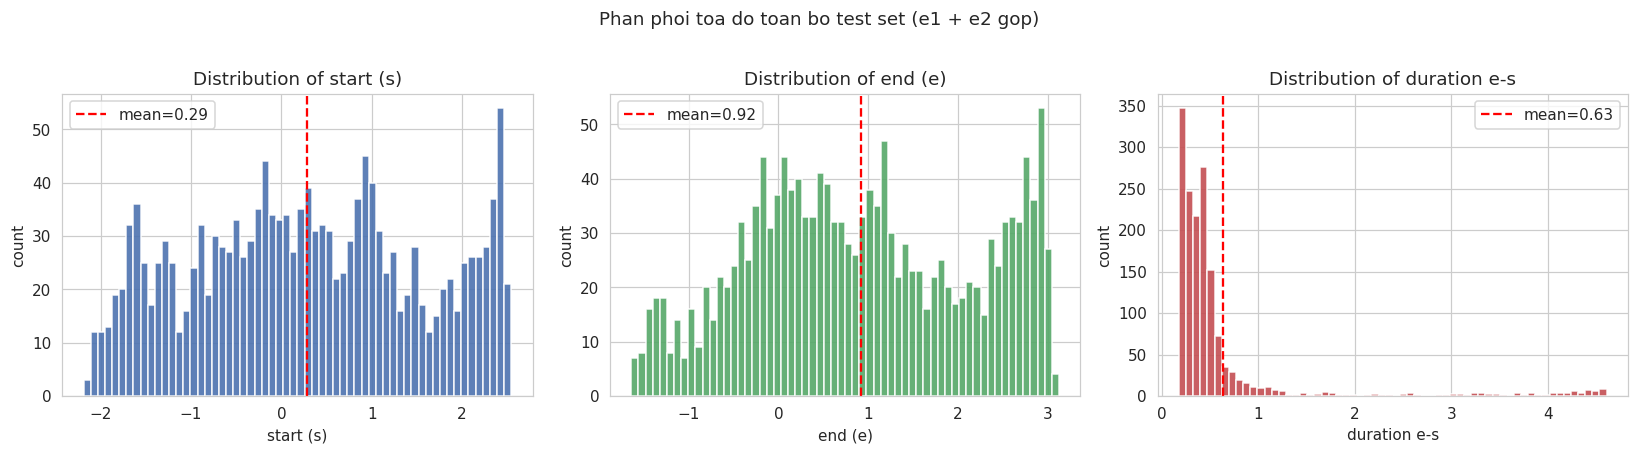

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (arr,label,color) in zip(axes, [
    (all_s,   "start (s)",     "#4C72B0"),
    (all_e,   "end (e)",       "#55A868"),
    (all_dur, "duration e-s",  "#C44E52")]):
    ax.hist(arr, bins=60, color=color, edgecolor="white", alpha=0.9)
    ax.axvline(arr.mean(), color="red", ls="--", lw=1.5, label=f"mean={arr.mean():.2f}")
    ax.set_title(f"Distribution of {label}")
    ax.set_xlabel(label); ax.set_ylabel("count"); ax.legend()
plt.suptitle("Phan phoi toa do toan bo test set (e1 + e2 gop)", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/A_global_coords.png", bbox_inches="tight"); plt.show()

---
## §B. Tính nhất quán tọa độ của cùng 1 event qua nhiều cặp

Một event có thể xuất hiện trong nhiều cặp khác nhau trong cùng document.
Consistency loss kỳ vọng tọa độ của event đó **ổn định** qua mọi lần xuất hiện.

Events xuat hien >= 2 cap: 268 / 296 (90.5%)
So cap trung binh / event   : 5.8  (max=13)

Mean std(s) = 0.3451   Median = 0.2611
Mean std(e) = 0.3446   Median = 0.2665
Mean duration               = 0.6916
Relative jitter = std(s)/dur= 0.499
  (< 0.1: rat on dinh | > 0.3: dao dong dang ke)

7.5% events co std(s) < 0.05  -> on dinh tot
73.9% events co std(s) > 0.15 -> dao dong dang ke


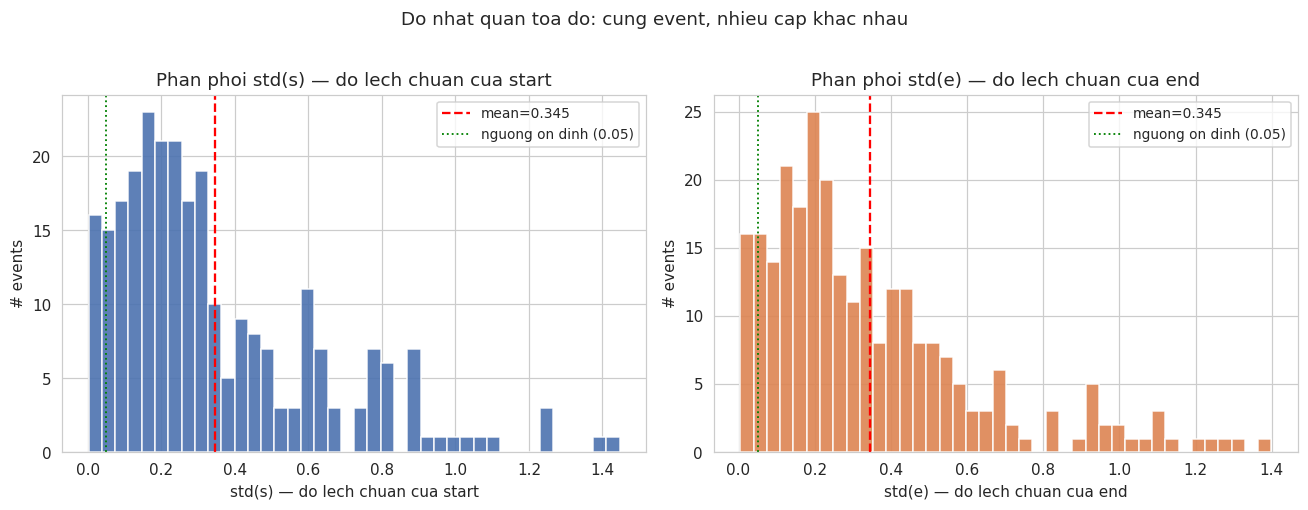

In [11]:
ev_s = defaultdict(list); ev_e = defaultdict(list)
for _, r in df.iterrows():
    ev_s[r.event1].append(r.s1); ev_e[r.event1].append(r.e1)
    ev_s[r.event2].append(r.s2); ev_e[r.event2].append(r.e2)

multi   = [e for e, v in ev_s.items() if len(v) >= 2]
s_std   = np.array([np.std(ev_s[e])  for e in multi])
e_std   = np.array([np.std(ev_e[e])  for e in multi])
dur_avg = np.array([np.mean(ev_e[e]) - np.mean(ev_s[e]) for e in multi])
n_pairs = np.array([len(ev_s[e]) for e in multi])

pct_multi = len(multi)/len(ev_s)*100
n_stable  = (s_std < 0.05).sum()
n_unstable= (s_std > 0.15).sum()
rel_jitter = s_std.mean() / dur_avg.mean()

msg = (
    f"Events xuat hien >= 2 cap: {len(multi)} / {len(ev_s)} ({pct_multi:.1f}%)\n"
    f"So cap trung binh / event   : {n_pairs.mean():.1f}  (max={n_pairs.max()})\n"
    f"\nMean std(s) = {s_std.mean():.4f}   Median = {np.median(s_std):.4f}\n"
    f"Mean std(e) = {e_std.mean():.4f}   Median = {np.median(e_std):.4f}\n"
    f"Mean duration               = {dur_avg.mean():.4f}\n"
    f"Relative jitter = std(s)/dur= {rel_jitter:.3f}\n"
    f"  (< 0.1: rat on dinh | > 0.3: dao dong dang ke)\n"
    f"\n{n_stable/len(s_std)*100:.1f}% events co std(s) < 0.05  -> on dinh tot\n"
    f"{n_unstable/len(s_std)*100:.1f}% events co std(s) > 0.15 -> dao dong dang ke"
)
print(msg)

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
for ax, (arr, label, color) in zip(axes, [
    (s_std, "std(s) — do lech chuan cua start", "#4C72B0"),
    (e_std, "std(e) — do lech chuan cua end",   "#DD8452")]):
    ax.hist(arr, bins=40, color=color, edgecolor="white", alpha=0.9)
    ax.axvline(arr.mean(), color="red", ls="--", lw=1.5, label=f"mean={arr.mean():.3f}")
    ax.axvline(0.05, color="green", ls=":", lw=1.2, label="nguong on dinh (0.05)")
    ax.set_xlabel(label); ax.set_ylabel("# events")
    ax.set_title(f"Phan phoi {label}"); ax.legend(fontsize=9)
plt.suptitle("Do nhat quan toa do: cung event, nhieu cap khac nhau", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/D_consistency.png", bbox_inches="tight"); plt.show()

## §C. Hai nhanh dong y / bat dong

In [12]:
# Lay thang tu bien da co trong cell inference
agree               = (preds_sem == preds_geo)
both_right          = (preds_sem == labels) & (preds_geo == labels)
both_wrong          = (preds_sem != labels) & (preds_geo != labels)
sem_right_geo_wrong = (preds_sem == labels) & (preds_geo != labels)
sem_wrong_geo_right = (preds_sem != labels) & (preds_geo == labels)

n = len(df)
msg = (
    f"===== Tuong quan giua 2 nhanh =====\n"
    f"  Ty le 2 nhanh DONG Y nhau  : {agree.mean()*100:.1f}%  ({agree.sum()} / {n})\n"
    f"\n  Trong do:\n"
    f"    [OK] Ca 2 cung DUNG       : {both_right.mean()*100:.1f}%  ({both_right.sum()} pairs)\n"
    f"    [X]  Ca 2 cung SAI        : {both_wrong.mean()*100:.1f}%  ({both_wrong.sum()} pairs)\n"
    f"\n  Ty le 2 nhanh BAT DONG    : {(~agree).mean()*100:.1f}%  ({(~agree).sum()} / {n})\n"
    f"\n  Trong do:\n"
    f"    Sem DUNG / Geo SAI        : {sem_right_geo_wrong.mean()*100:.1f}%  ({sem_right_geo_wrong.sum()} pairs)\n"
    f"    Sem SAI  / Geo DUNG       : {sem_wrong_geo_right.mean()*100:.1f}%  ({sem_wrong_geo_right.sum()} pairs)"
)
print(msg)

disagree_df     = df[preds_sem != preds_geo]
ens_follows_sem = (disagree_df.pred_ens == disagree_df.pred_sem).sum()
ens_follows_geo = (disagree_df.pred_ens == disagree_df.pred_geo).sum()
n_dis           = len(disagree_df)

msg2 = (
    f"\n  Khi 2 nhanh bat dong, ensemble theo:\n"
    f"    -> Semantic : {ens_follows_sem}/{n_dis} ({ens_follows_sem/n_dis*100:.1f}%)\n"
    f"    -> Geometric: {ens_follows_geo}/{n_dis} ({ens_follows_geo/n_dis*100:.1f}%)\n"
)
print(msg2)

===== Tuong quan giua 2 nhanh =====
  Ty le 2 nhanh DONG Y nhau  : 95.9%  (757 / 789)

  Trong do:
    [OK] Ca 2 cung DUNG       : 84.8%  (669 pairs)
    [X]  Ca 2 cung SAI        : 12.8%  (101 pairs)

  Ty le 2 nhanh BAT DONG    : 4.1%  (32 / 789)

  Trong do:
    Sem DUNG / Geo SAI        : 1.9%  (15 pairs)
    Sem SAI  / Geo DUNG       : 0.5%  (4 pairs)

  Khi 2 nhanh bat dong, ensemble theo:
    -> Semantic : 6/32 (18.8%)
    -> Geometric: 24/32 (75.0%)



In [13]:
def classify_err(r):
    cs, cg, ce = r.correct_sem, r.correct_geo, r.correct_ens
    if ce == 1:
        if cs == 1 and cg == 1: return "both_correct"
        if cs == 1 and cg == 0: return "sem_saved"
        if cs == 0 and cg == 1: return "geo_saved"
        return "ens_lucky"
    if cs == 0 and cg == 0:    return "both_wrong"
    if cs == 1 and cg == 0:    return "geo_drags_wrong"
    if cs == 0 and cg == 1:    return "sem_drags_wrong"
    return "other"

df["err_type"] = df.apply(classify_err, axis=1)

counts = df.err_type.value_counts()
n_err  = (df.correct_ens==0).sum()
print("===== Phan loai toan bo 789 test pairs =====")
print(counts)

===== Phan loai toan bo 789 test pairs =====
err_type
both_correct       669
both_wrong         100
geo_drags_wrong     11
geo_saved            4
sem_saved            4
ens_lucky            1
Name: count, dtype: int64


In [14]:
# ── Cột branch_status: chỉ xét Sem vs Geo, không xét ensemble ──
def get_branch_status(r):
    if r.correct_sem == 1 and r.correct_geo == 1: return "both_right"
    if r.correct_sem == 1 and r.correct_geo == 0: return "sem_right_geo_wrong"
    if r.correct_sem == 0 and r.correct_geo == 1: return "geo_right_sem_wrong"
    return "both_wrong"

df["branch_status"] = df.apply(get_branch_status, axis=1)

print("===== Branch-level (độc lập với ensemble) =====")
print(df["branch_status"].value_counts())
print()

# ── Bảng chéo: branch_status × err_type ──
print("===== Cross-table: branch_status × err_type =====")
print(pd.crosstab(df["branch_status"], df["err_type"]))

===== Branch-level (độc lập với ensemble) =====
branch_status
both_right             669
both_wrong             101
sem_right_geo_wrong     15
geo_right_sem_wrong      4
Name: count, dtype: int64

===== Cross-table: branch_status × err_type =====
err_type             both_correct  both_wrong  ens_lucky  geo_drags_wrong  \
branch_status                                                               
both_right                    669           0          0                0   
both_wrong                      0         100          1                0   
geo_right_sem_wrong             0           0          0                0   
sem_right_geo_wrong             0           0          0               11   

err_type             geo_saved  sem_saved  
branch_status                              
both_right                   0          0  
both_wrong                   0          0  
geo_right_sem_wrong          4          0  
sem_right_geo_wrong          0          4  


---
## §D. Tham số học được

In [15]:
TOL  = F.softplus(model.simul_threshold).item()
TEMP = (F.softplus(model.geo_temp) + 0.1).item()

print(f"simul_threshold (raw) = {model.simul_threshold.item():.6f}")
print(f"  -> tol = softplus(raw) = {TOL:.6f}")
print(f"     Y nghia: voi SIMULTANEOUS, cho phep |d_start|+|d_end| toi {2*TOL:.4f}")
print()
print(f"geo_temp (raw) = {model.geo_temp.item():.6f}")
print(f"  -> temp = softplus(raw)+0.1 = {TEMP:.6f}")
print(f"     Y nghia: logits hinh hoc duoc chia cho gia tri nay truoc softmax")
print(f"     temp nho -> phan phoi nhon (tu tin) | temp lon -> phan phoi phang (it tu tin)")

simul_threshold (raw) = -1.999565
  -> tol = softplus(raw) = 0.126980
     Y nghia: voi SIMULTANEOUS, cho phep |d_start|+|d_end| toi 0.2540

geo_temp (raw) = -0.005564
  -> temp = softplus(raw)+0.1 = 0.790369
     Y nghia: logits hinh hoc duoc chia cho gia tri nay truoc softmax
     temp nho -> phan phoi nhon (tu tin) | temp lon -> phan phoi phang (it tu tin)


## §E. Timeline reconstruction — Mo hinh dung lai dong thoi gian cua document

Timeline duoc xay dung tu **toa do trung binh** cua moi event qua tat ca cac cap no tham gia:
- Moi thanh mau = 1 event voi khoang [s_mean, e_mean], sap xep theo thu tu thoi gian
- **Duong xanh** = cap Ensemble du doan DUNG
- **Duong cam** = cap Ensemble du doan SAI

In [16]:
import matplotlib.cm as cm

ev_s_lst = defaultdict(list); ev_e_lst = defaultdict(list); ev_text = {}
for _, r in df.iterrows():
    ev_s_lst[r.event1].append(r.s1); ev_e_lst[r.event1].append(r.e1)
    ev_s_lst[r.event2].append(r.s2); ev_e_lst[r.event2].append(r.e2)
for _, r in test_df.iterrows():
    k1 = f"{r['document_id']}_{r['entity1_id']}"
    k2 = f"{r['document_id']}_{r['entity2_id']}"
    ev_text[k1] = r["entity1_text"]; ev_text[k2] = r["entity2_text"]

doc_acc = df.groupby("doc_id").agg(
    n  =("correct_ens","size"),
    acc=("correct_ens","mean")).sort_values("acc", ascending=False)
print("Tat ca documents (sap xep theo accuracy ensemble):")
print(doc_acc.to_string())

Tat ca documents (sap xep theo accuracy ensemble):
                         n       acc
doc_id                              
NYT19980402.0453       129  0.922481
APW19980227.0489       104  0.894231
APW19980418.0210        40  0.875000
APW19980227.0494       206  0.868932
APW19980308.0201        61  0.868852
PRI19980115.2000.0186   74  0.864865
CNN19980213.2130.0155  121  0.834711
CNN19980126.1600.1104   12  0.833333
PRI19980306.2000.1675   42  0.571429


In [17]:
def plot_timeline(doc_id, df, ev_text_map, top_n=None, save_path=None):
    doc_rows = df[df.doc_id == doc_id].copy()
    if len(doc_rows) == 0:
        print(f"Khong tim thay document {doc_id}"); return

    # Gom toa do trung binh + min/max per event (the hien do khong nhat quan)
    tmp = defaultdict(lambda: {"s":[], "e":[], "text":"", "eid":""})
    for _, r in doc_rows.iterrows():
        tmp[r.event1]["s"].append(r.s1); tmp[r.event1]["e"].append(r.e1)
        tmp[r.event1]["text"] = ev_text_map.get(r.event1, r.event1.split("_")[-1])
        tmp[r.event1]["eid"]  = r.event1.split("_")[-1]
        tmp[r.event2]["s"].append(r.s2); tmp[r.event2]["e"].append(r.e2)
        tmp[r.event2]["text"] = ev_text_map.get(r.event2, r.event2.split("_")[-1])
        tmp[r.event2]["eid"]  = r.event2.split("_")[-1]

    event_map = {
        k: {"s_mean": np.mean(v["s"]), "e_mean": np.mean(v["e"]),
            "s_min":  np.min(v["s"]),  "e_max":  np.max(v["e"]),
            "text": v["text"],         "eid":  v["eid"]}
        for k, v in tmp.items()
    }

    # Sort by mean start, keep top_n
    events_sorted = sorted(event_map.items(), key=lambda x: x[1]["s_mean"])
    if top_n is not None:
        events_sorted = events_sorted[:top_n]
    n = len(events_sorted)

    cmap   = plt.colormaps.get_cmap("tab20")
    colors = [cmap(i % 20) for i in range(n)]
    eid_to_idx = {key: i for i, (key, _) in enumerate(events_sorted)}

    fig, ax = plt.subplots(figsize=(16, max(6, n * 0.48)))

    for i, (key, data) in enumerate(events_sorted):
        s_mean = data["s_mean"]; e_mean = data["e_mean"]
        s_min  = data["s_min"];  e_max  = data["e_max"]

        # Vung mo = range min->max (the hien do dao dong toa do)
        ax.barh(i, width=e_max - s_min, left=s_min, height=0.55,
                color=colors[i], alpha=0.20, edgecolor="none")

        # Thanh dam = mean
        ax.barh(i, width=e_mean - s_mean, left=s_mean, height=0.55,
                color=colors[i], alpha=0.85, edgecolor="black", linewidth=0.5)

        # Marker start (tam giac xuong) va end (tam giac len)
        ax.plot(s_mean, i, "v", color="navy",    markersize=6, alpha=0.9)
        ax.plot(e_mean, i, "^", color="darkred", markersize=6, alpha=0.9)

        # Label ben phai
        short = data["text"][:14] if len(data["text"]) <= 14 else data["text"][:13]+"..."
        ax.text(e_mean + 0.03, i, f"{data['eid']}: {short}",
                va="center", fontsize=8)

    # Ve cac canh quan he giua cac cap (ket qua ensemble)
    visible = set(eid_to_idx.keys())
    for _, r in doc_rows.iterrows():
        k1, k2 = r.event1, r.event2
        if k1 not in visible or k2 not in visible: continue
        y1, y2 = eid_to_idx[k1], eid_to_idx[k2]
        x1 = event_map[k1]["e_mean"]
        x2 = event_map[k2]["s_mean"]
        if r.correct_ens:
            color, lw, alpha = "#29B6F6", 2.0, 0.45   # xanh nhat, trong suot
        else:
            color, lw, alpha = "#FF6D00", 1.8, 0.85   # cam dam, duc
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color=color, lw=lw, alpha=alpha))

    n_ok = doc_rows.correct_ens.sum(); n_total = len(doc_rows)
    acc  = n_ok / n_total

    ax.set_yticks(range(n))
    ax.set_yticklabels([d["eid"] for _, d in events_sorted], fontsize=8)
    ax.set_xlabel("Temporal Coordinate (toa do thoi gian hoc duoc)", fontsize=10)
    ax.set_title(f"v = start  |  ^ = end  |  blue=correct, orange=wrong", fontsize=9)
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.invert_yaxis()

    ax.text(0.01, 1.025,
            f"Doc accuracy: {acc:.2%}  ({n_ok}/{n_total} correct)",
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.85))

    fig.suptitle(f"Timeline: {doc_id}  |  {n_total} pairs, {len(event_map)} events",
                 fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    # In bang tom tat cac cap
    print(f"\nCac cap trong document {doc_id}:")
    show_cols = ["event1","event2","label_name","pred_ens","correct_ens","s1","e1","s2","e2"]
    show_cols = [c for c in show_cols if c in doc_rows.columns]
    print(doc_rows[show_cols].rename(columns={
        "label_name":"gold","pred_ens":"pred","correct_ens":"ok"}).to_string(index=False))

In [18]:
# Build ev_text_map tu test_df
ev_text_map = {}
for _, r in test_df.iterrows():
    k1 = f"{r['document_id']}_{r['entity1_id']}"
    k2 = f"{r['document_id']}_{r['entity2_id']}"
    ev_text_map[k1] = r["entity1_text"]
    ev_text_map[k2] = r["entity2_text"]

# Xep hang document theo accuracy
doc_acc = df.groupby("doc_id").agg(
    n   =("correct_ens","size"),
    acc =("correct_ens","mean")
).sort_values("acc", ascending=False)

doc_counts = df.groupby("doc_id").size().sort_values(ascending=False)

print("=== Tat ca documents (sap xep theo so cap) ===")
for doc_id, cnt in doc_counts.items():
    acc_val = doc_acc.loc[doc_id, "acc"]
    print(f"  {doc_id}  |  pairs={cnt}  |  acc={acc_val:.2%}")

print("\n=== Top 5 document accuracy cao nhat ===")
for doc_id in doc_acc.head(5).index:
    row = doc_acc.loc[doc_id]
    print(f"  {doc_id}  |  pairs={int(row.n)}  |  acc={row.acc:.2%}")

print("\n=== Top 5 document accuracy thap nhat ===")
for doc_id in doc_acc.tail(5).index:
    row = doc_acc.loc[doc_id]
    print(f"  {doc_id}  |  pairs={int(row.n)}  |  acc={row.acc:.2%}")

=== Tat ca documents (sap xep theo so cap) ===
  APW19980227.0494  |  pairs=206  |  acc=86.89%
  NYT19980402.0453  |  pairs=129  |  acc=92.25%
  CNN19980213.2130.0155  |  pairs=121  |  acc=83.47%
  APW19980227.0489  |  pairs=104  |  acc=89.42%
  PRI19980115.2000.0186  |  pairs=74  |  acc=86.49%
  APW19980308.0201  |  pairs=61  |  acc=86.89%
  PRI19980306.2000.1675  |  pairs=42  |  acc=57.14%
  APW19980418.0210  |  pairs=40  |  acc=87.50%
  CNN19980126.1600.1104  |  pairs=12  |  acc=83.33%

=== Top 5 document accuracy cao nhat ===
  NYT19980402.0453  |  pairs=129  |  acc=92.25%
  APW19980227.0489  |  pairs=104  |  acc=89.42%
  APW19980418.0210  |  pairs=40  |  acc=87.50%
  APW19980227.0494  |  pairs=206  |  acc=86.89%
  APW19980308.0201  |  pairs=61  |  acc=86.89%

=== Top 5 document accuracy thap nhat ===
  APW19980308.0201  |  pairs=61  |  acc=86.89%
  PRI19980115.2000.0186  |  pairs=74  |  acc=86.49%
  CNN19980213.2130.0155  |  pairs=121  |  acc=83.47%
  CNN19980126.1600.1104  |  pai

Timeline doc tot nhat: NYT19980402.0453  (acc=92.25%)


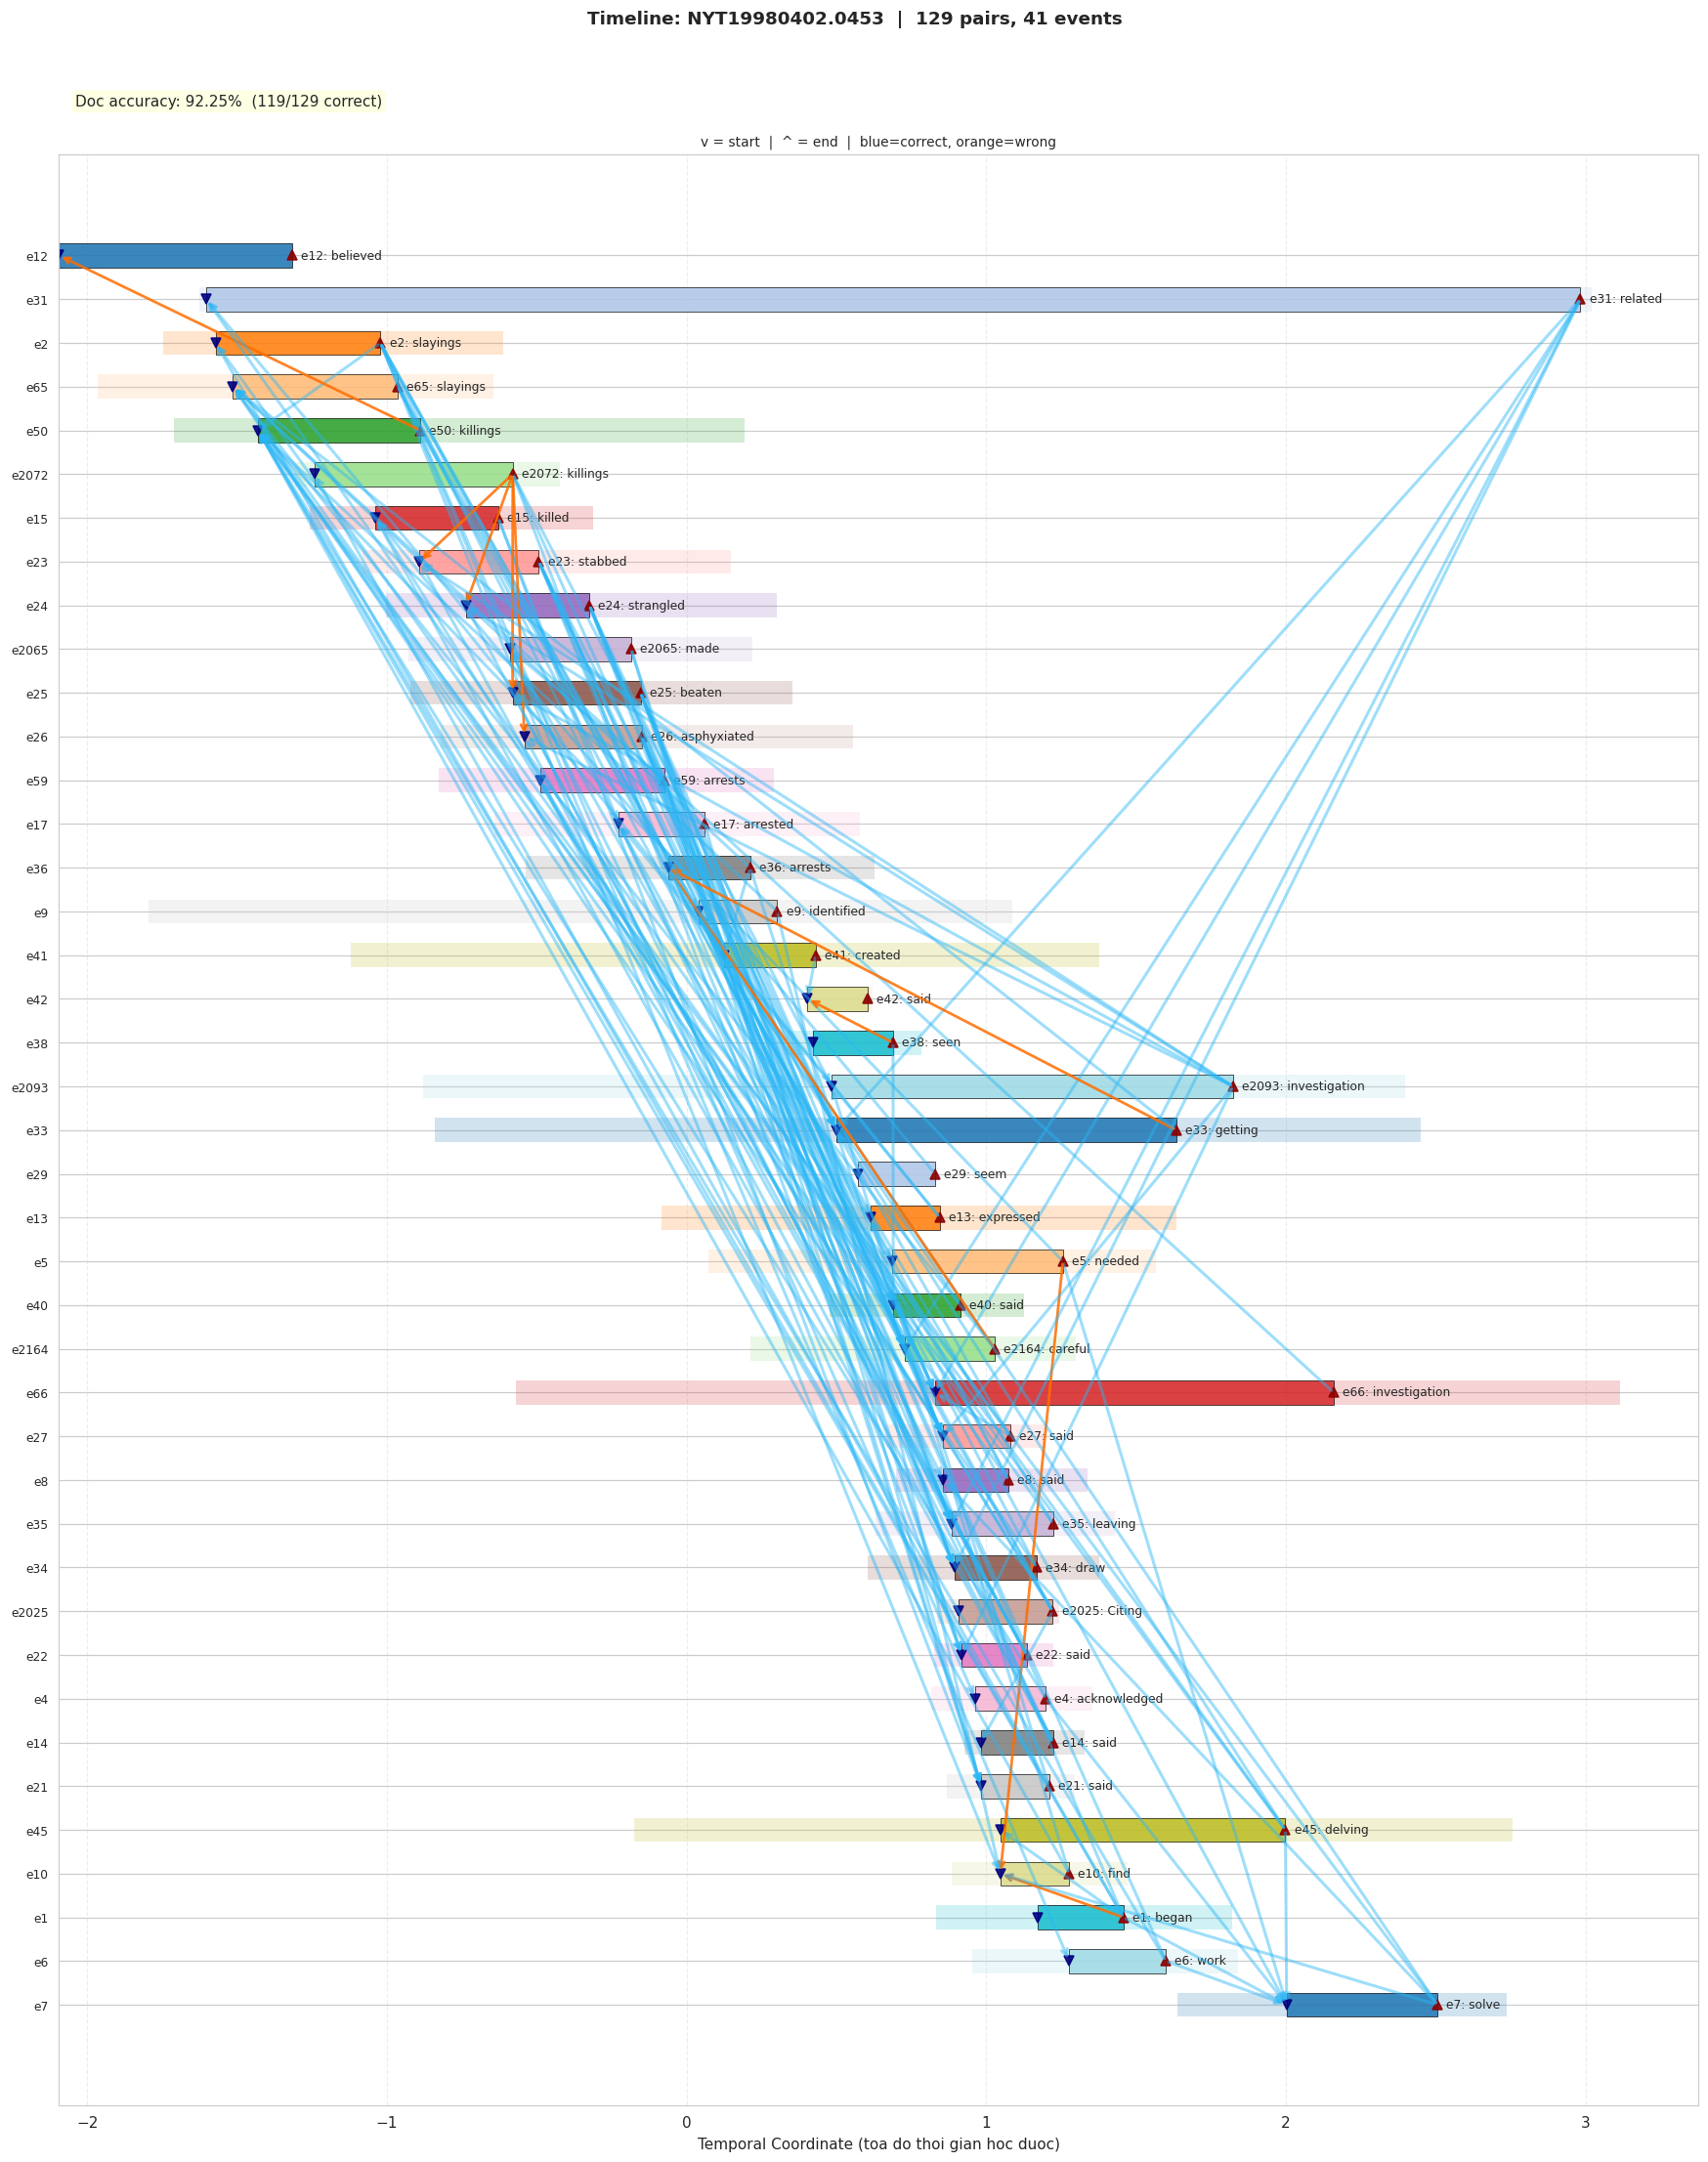


Cac cap trong document NYT19980402.0453:
                event1                 event2         gold  pred  ok        s1        e1        s2        e2
   NYT19980402.0453_e1   NYT19980402.0453_e45  IS_INCLUDED     3   1  0.833448  1.078531 -0.175423  2.756657
   NYT19980402.0453_e1    NYT19980402.0453_e2        AFTER     1   1  1.269451  1.538916 -1.609103 -1.061521
   NYT19980402.0453_e1    NYT19980402.0453_e7       BEFORE     0   1  1.124991  1.418303  1.806516  2.389717
  NYT19980402.0453_e45    NYT19980402.0453_e2        AFTER     1   1  1.315428  1.720475 -1.745439 -1.249952
  NYT19980402.0453_e45    NYT19980402.0453_e7       BEFORE     0   1  1.235150  1.700750  1.772995  2.371281
   NYT19980402.0453_e2    NYT19980402.0453_e4       BEFORE     0   1 -1.539268 -0.911960  1.098408  1.354342
   NYT19980402.0453_e2    NYT19980402.0453_e5       BEFORE     0   1 -1.638490 -1.163262  1.168661  1.564777
   NYT19980402.0453_e2    NYT19980402.0453_e6       BEFORE     0   1 -1.568056 -1.0896

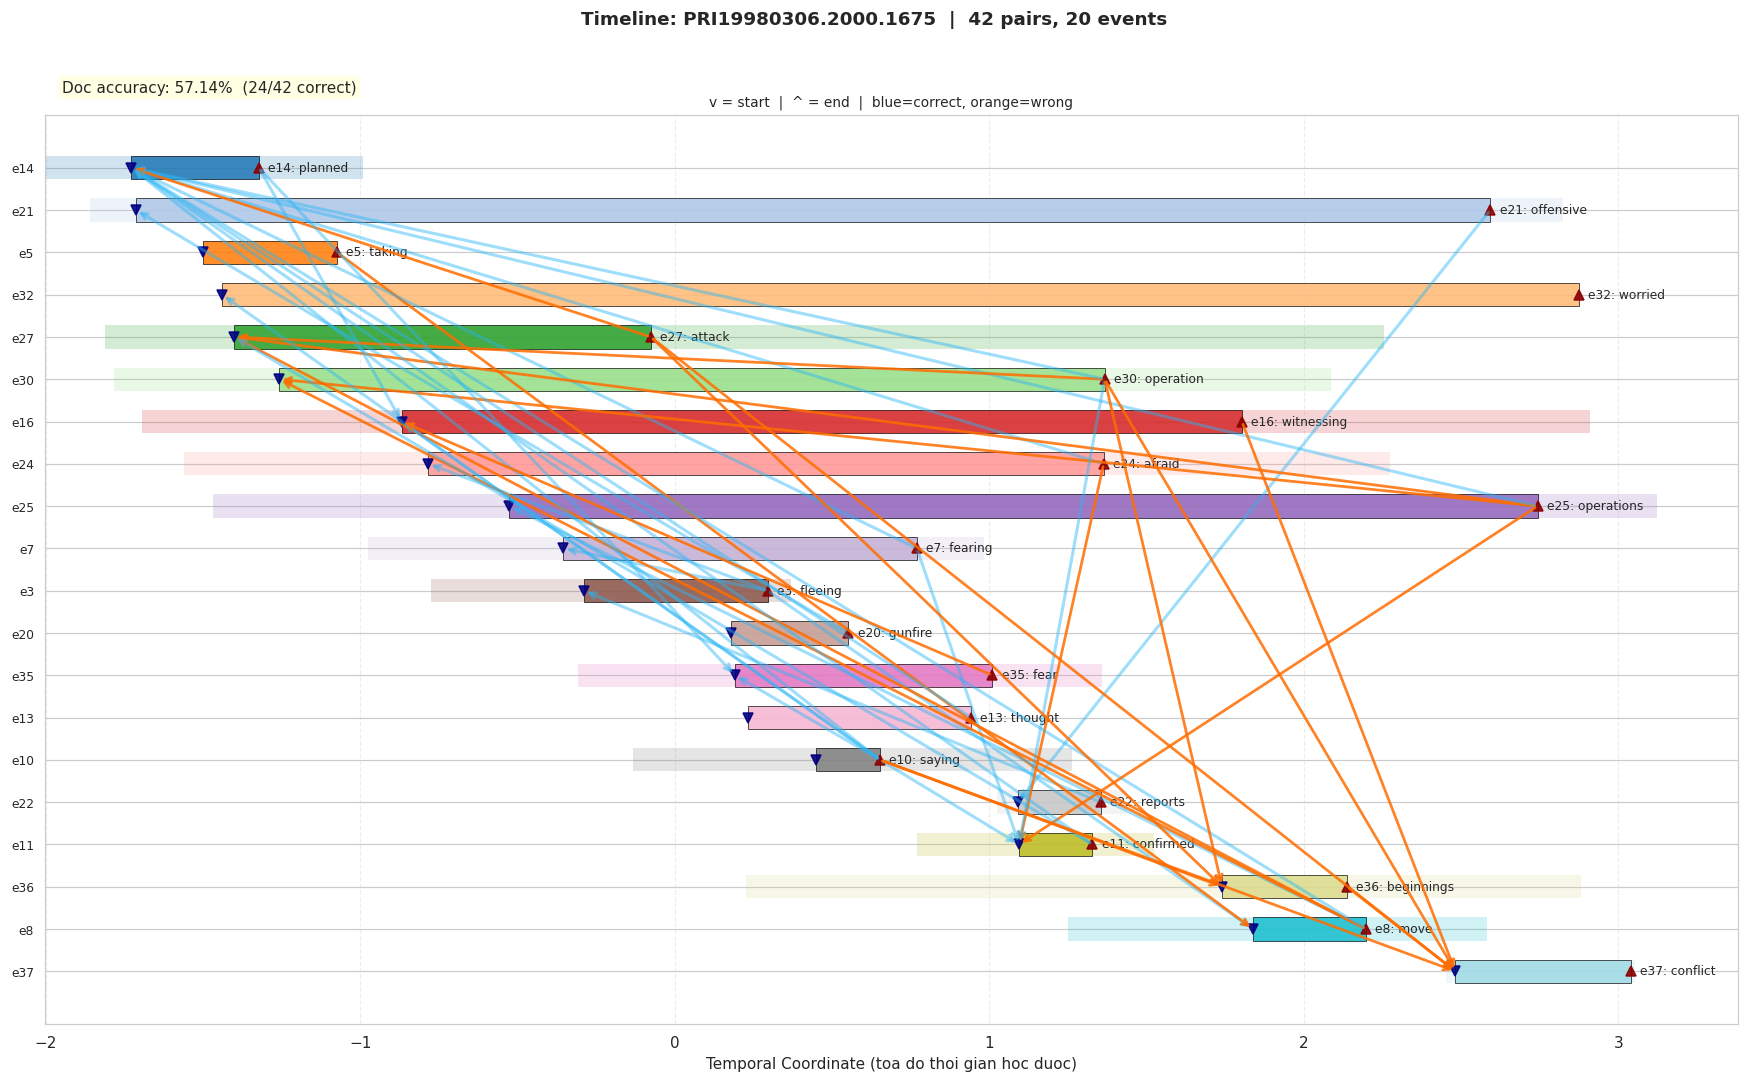


Cac cap trong document PRI19980306.2000.1675:
                   event1                    event2         gold  pred  ok        s1        e1        s2        e2
PRI19980306.2000.1675_e20 PRI19980306.2000.1675_e21  IS_INCLUDED     3   1  0.180223  0.551949 -1.567473  2.825160
PRI19980306.2000.1675_e21 PRI19980306.2000.1675_e22     INCLUDES     2   1 -1.857764  2.360867  1.024220  1.272536
PRI19980306.2000.1675_e22  PRI19980306.2000.1675_e3        AFTER     1   1  1.159594  1.436477 -0.775629  0.274143
 PRI19980306.2000.1675_e3 PRI19980306.2000.1675_e24  IS_INCLUDED     3   1  0.012605  0.370966 -1.155314  0.808060
 PRI19980306.2000.1675_e3  PRI19980306.2000.1675_e7  IS_INCLUDED     3   1 -0.134312  0.363039 -0.543186  0.472497
 PRI19980306.2000.1675_e3  PRI19980306.2000.1675_e8       BEFORE     0   1 -0.259673  0.175218  2.165355  2.582259
 PRI19980306.2000.1675_e5  PRI19980306.2000.1675_e8     INCLUDES     0   0 -1.500825 -1.073305  2.119507  2.527654
 PRI19980306.2000.1675_e8 PRI1998

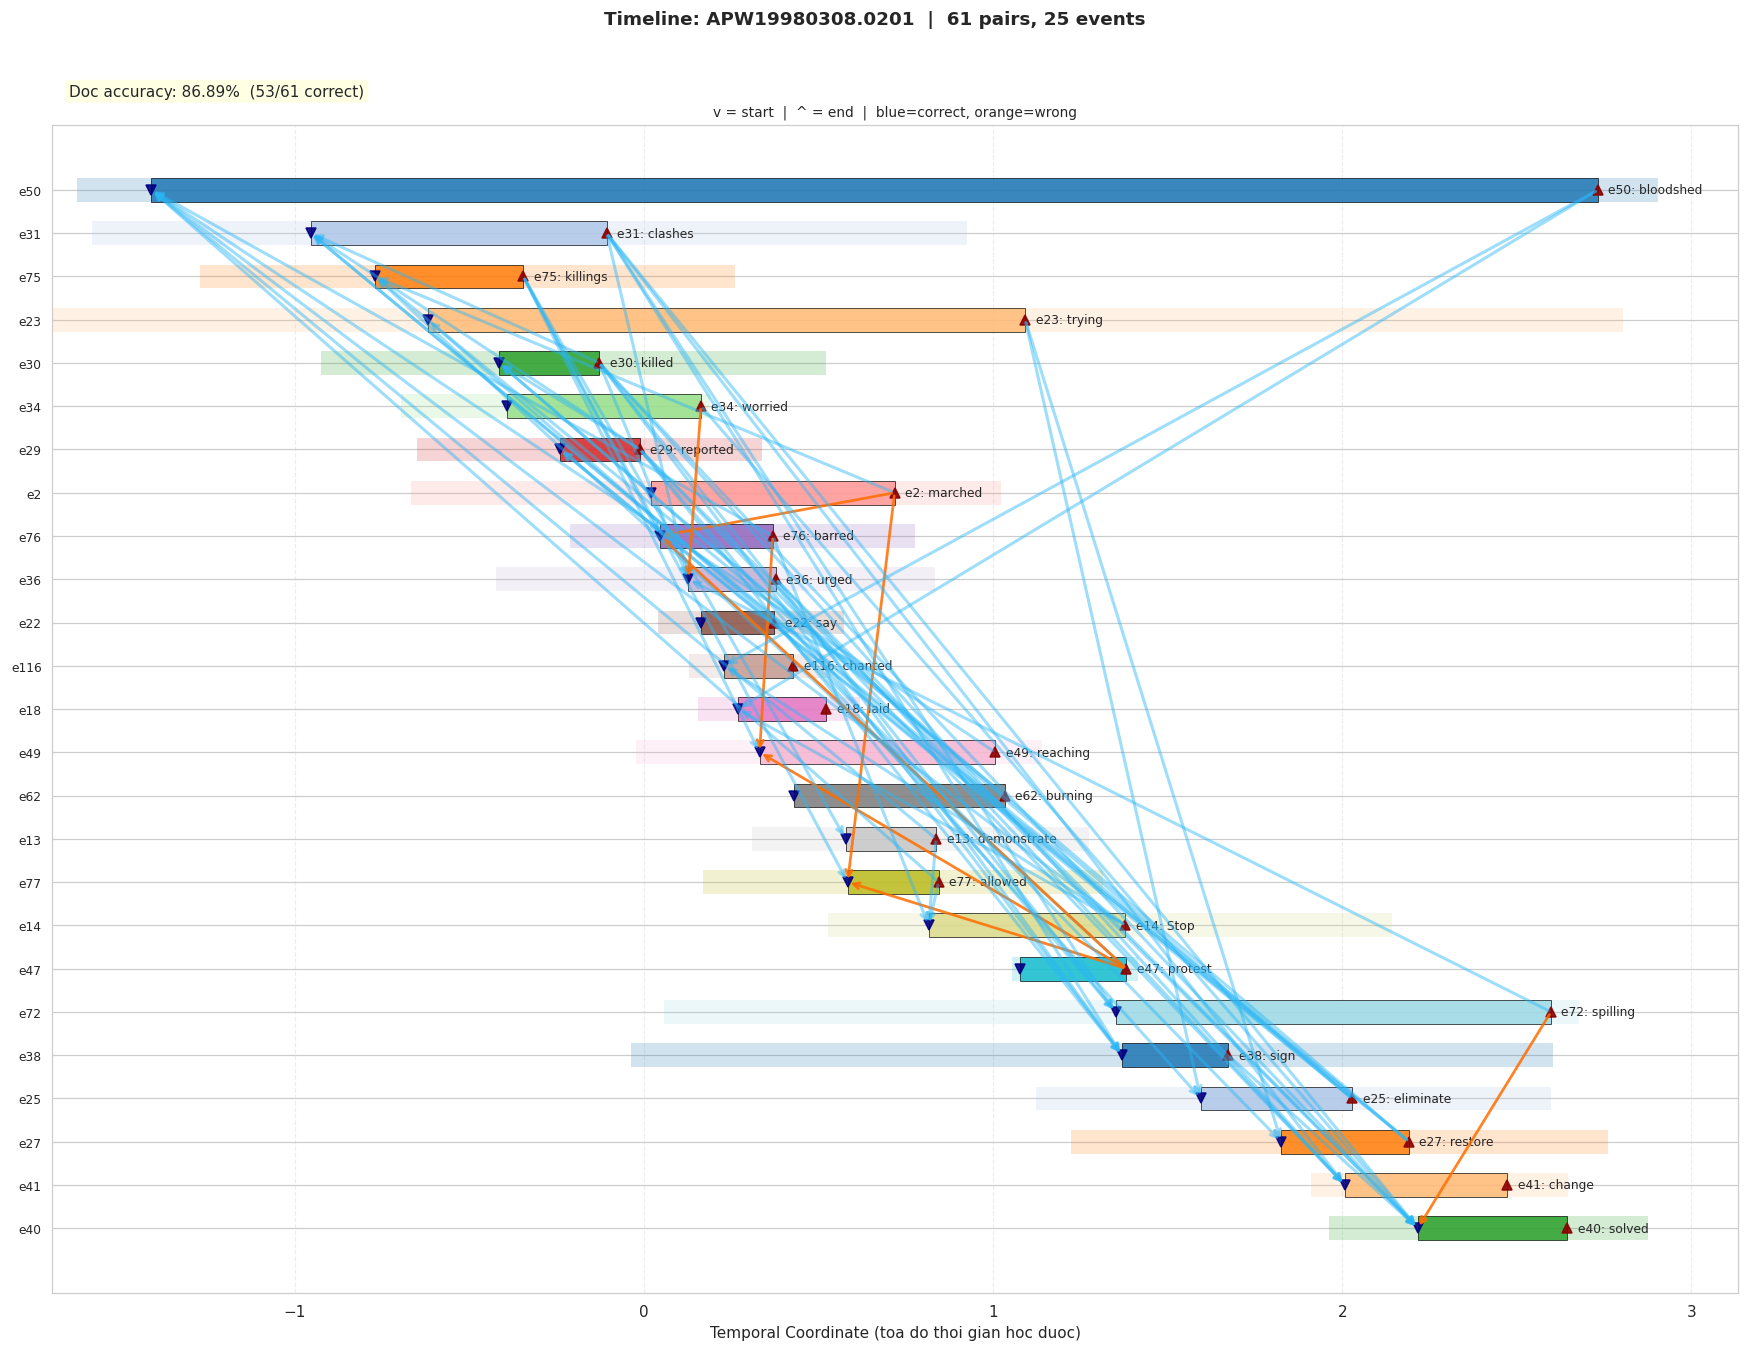


Cac cap trong document APW19980308.0201:
              event1                event2        gold  pred  ok        s1        e1        s2        e2
 APW19980308.0201_e2  APW19980308.0201_e75       AFTER     1   1  0.709839  1.021856 -0.973591 -0.546690
APW19980308.0201_e62  APW19980308.0201_e75       AFTER     1   1  0.430173  1.034075 -0.741915 -0.203883
APW19980308.0201_e47  APW19980308.0201_e75       AFTER     1   1  1.059062  1.330254 -1.272584 -0.854183
 APW19980308.0201_e2  APW19980308.0201_e76    INCLUDES     1   0  0.022624  0.634562 -0.117536  0.259267
 APW19980308.0201_e2  APW19980308.0201_e77    INCLUDES     0   0 -0.668089  0.497560  0.531103  0.806578
APW19980308.0201_e47  APW19980308.0201_e76    INCLUDES     1   0  1.082193  1.408013  0.074302  0.453689
APW19980308.0201_e47  APW19980308.0201_e49    INCLUDES     1   0  1.112502  1.413868  0.348651  0.963812
APW19980308.0201_e47  APW19980308.0201_e77    INCLUDES     1   0  1.055218  1.373824  0.839168  1.129954
APW19980308.0

In [19]:
# Ve timeline doc tot nhat
top_doc = doc_acc.index[0]
top_acc_val = doc_acc.loc[top_doc,"acc"]
print(f"Timeline doc tot nhat: {top_doc}  (acc={top_acc_val:.2%})")
plot_timeline(top_doc, df, ev_text_map, save_path=f"{OUT_DIR}/J_timeline_best.png")

# Ve timeline doc kem nhat
bot_doc = doc_acc.index[-1]
bot_acc_val = doc_acc.loc[bot_doc,"acc"]
print(f"\nTimeline doc kem nhat: {bot_doc}  (acc={bot_acc_val:.2%})")
plot_timeline(bot_doc, df, ev_text_map, save_path=f"{OUT_DIR}/J_timeline_worst.png")

# Ve timeline doc trung binh
mid_doc = doc_acc.index[len(doc_acc)//2]
mid_acc_val = doc_acc.loc[mid_doc,"acc"]
print(f"\nTimeline doc trung binh: {mid_doc}  (acc={mid_acc_val:.2%})")
plot_timeline(mid_doc, df, ev_text_map, save_path=f"{OUT_DIR}/J_timeline_mid.png")

print("""
Cach doc timeline:
- Thanh dam   : khoang thoi gian trung binh [s_mean, e_mean] cua event
- Vung mo     : khoang dao dong [s_min, e_max] — the hien su thieu nhat quan toa do
- Tam giac v  : diem start (s_mean)
- Tam giac ^  : diem end   (e_mean)
- Mui ten xanh: cap du doan DUNG (Ensemble)
- Mui ten cam : cap du doan SAI  (Ensemble)
- Y-axis      : sap xep tu tren xuong duoi theo thu tu thoi gian (s_mean nho -> lon)
""")

# De ve doc khac: plot_timeline("ten_doc_id", df, ev_text_map)

## §F. Case studies — Phan tich vi du cu the voi logits hinh hoc

In [20]:
def geom_ok(row):
    c = row.label; ds = row.d_start; de = row.d_end
    if c == 0: return (row.s2 - row.e1) > 0
    if c == 1: return (row.s1 - row.e2) > 0
    if c == 2: return (ds > TOL) and (de > TOL)
    if c == 3: return (-ds > TOL) and (-de > TOL)
    if c == 4: return abs(ds) + abs(de) < 2*TOL
    return False

df["geom_ok"] = df.apply(geom_ok, axis=1).astype(int)

summary = df.groupby("label_name").agg(
    n          = ("geom_ok","size"),
    pct_geom_ok= ("geom_ok","mean"),
    acc_sem    = ("correct_sem","mean"),
    acc_geo    = ("correct_geo","mean"),
    acc_ens    = ("correct_ens","mean")
).reindex(LABEL_NAMES).round(4)


In [21]:
# ══════════════════════════════════════════════════════════
# §K. Case Studies
# ══════════════════════════════════════════════════════════

def compute_geo_logits(s1, e1, s2, e2):
    ds  = s2 - s1
    de  = e1 - e2
    raw = np.array([
        s2 - e1,                      # BEFORE
        s1 - e2,                      # AFTER
        min(ds, de) - TOL,            # INCLUDES
        min(-ds, -de) - TOL,          # IS_INCLUDED
        2*TOL - (abs(ds) + abs(de)),  # SIMULTANEOUS
    ])
    logits = raw / TEMP
    # Softmax ổn định (trừ max trước)
    shifted = logits - logits.max()
    exp     = np.exp(shifted)
    probs   = exp / exp.sum()
    return raw, logits, probs


def show_case(idx):
    r    = df.iloc[idx]
    orig = test_df.iloc[r.row_idx]

    raw, logits, probs = compute_geo_logits(r.s1, r.e1, r.s2, r.e2)

    # ── Header ──
    print("=" * 78)
    print(f"Doc: {r.doc_id}  |  {r.event1}  <->  {r.event2}")
    print(f"Gold: {r.label_name:13s}  "
          f"Pred Sem: {LABEL_NAMES[r.pred_sem]:13s} ({r.conf_sem:.2f})  "
          f"Pred Geo: {LABEL_NAMES[r.pred_geo]:13s} ({r.conf_geo:.2f})  "
          f"Pred Ens: {LABEL_NAMES[r.pred_ens]:13s} ({r.conf_ens:.2f})")
    print(f"s1={r.s1:.3f}  e1={r.e1:.3f}  (dur={r.dur1:.3f})")
    print(f"s2={r.s2:.3f}  e2={r.e2:.3f}  (dur={r.dur2:.3f})")
    print(f"d_start = s2-s1 = {r.d_start:+.3f}    d_end = e1-e2 = {r.d_end:+.3f}")
    print(f"geom_ok (thoa rang buoc gold): {bool(r.geom_ok)}")
    print(f"Entity1: {orig['entity1_text']!r:25s}  Entity2: {orig['entity2_text']!r:25s}")
    print(f"Err type: {r.err_type}")

   # ── Hien thi processed_text (dam bao hien thi du ca E1 va E2) ──
    proc = orig.get("processed_text", "")
    
    # Thay tag truoc khi tim vi tri
    proc = proc.replace("<e1>",  ">>E1[")
    proc = proc.replace("</e1>", "]<<")
    proc = proc.replace("<e2>",  ">>E2[")
    proc = proc.replace("</e2>", "]<<")
    
    # Tim vi tri cuoi cung cua E2 (hoac E1 neu E2 truoc E1)
    pos_e1 = proc.find(">>E1[")
    pos_e2 = proc.find(">>E2[")
    last_entity_end = 0
    
    if pos_e1 >= 0 and pos_e2 >= 0:
        # Vi tri ket thuc cua entity xuat hien sau cung
        last_tag_start = max(pos_e1, pos_e2)
        # Tim "]<<" tiep theo sau last_tag_start
        close_pos = proc.find("]<<", last_tag_start)
        last_entity_end = close_pos + 3 if close_pos >= 0 else last_tag_start + 50
    
    # Lay them 80 ky tu sau entity cuoi cung (de co context)
    cut_end = min(last_entity_end + 80, len(proc))
    # Tim ranh gioi tu gan nhat
    space_pos = proc.find(" ", cut_end)
    if space_pos > 0 and space_pos < cut_end + 30:
        cut_end = space_pos
    
    proc_display = proc[:cut_end]
    if cut_end < len(proc):
        proc_display += " ..."
    
    # Neu van qua dai (truong hop [SEP] — 2 chunk rieng) thi cat them
    if len(proc_display) > 600:
        proc_display = proc_display[:600] + " ..."
    
    print(f"\n  Context:")
    print(f"  {proc_display}\n")

    # ── Mini plot ──
    fig, ax = plt.subplots(figsize=(10, 2))
    ax.barh(0, r.e1 - r.s1, left=r.s1, height=0.3,
            color="#4C72B0", label=f"E1 ({orig['entity1_text']})")
    ax.barh(1, r.e2 - r.s2, left=r.s2, height=0.3,
            color="#C44E52", label=f"E2 ({orig['entity2_text']})")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["E1", "E2"])
    ax.set_title(f"Gold={r.label_name} | Ens pred={LABEL_NAMES[r.pred_ens]}")
    ax.legend(fontsize=8)
    ax.set_xlabel("temporal coord")
    plt.tight_layout()
    plt.show()

    # ── Geo Logits ──
    BAR_W = 25
    print(f"  Geo Logits  (tol={TOL:.3f}, temp={TEMP:.3f}):")
    print(f"  {'Class':13s}  {'raw':>8}  {'logit':>8}  {'prob':>6}  "
          f"{'probability bar':<{BAR_W+2}}")
    print(f"  {'-'*70}")
    for i, name in enumerate(LABEL_NAMES):
        gold_mark = "  <- GOLD" if i == r.label else ""
        bar_len   = round(probs[i] * BAR_W)
        bar       = "|" + "#" * bar_len + " " * (BAR_W - bar_len) + "|"
        print(f"  {name:13s}  {raw[i]:+8.3f}  {logits[i]:+8.3f}  "
              f"{probs[i]:6.3f}  {bar}{gold_mark}")
    pred_name = LABEL_NAMES[probs.argmax()]
    match_str = "khop" if pred_name == LABEL_NAMES[r.pred_geo] else "KHONG khop(!)"
    print(f"\n  => argmax(geo_probs) = {pred_name}  ({match_str} voi pred_geo)")
    print()


+========================================+
|  CASE 1: Ca 2 DUNG (high confidence)  |
+========================================+

Doc: APW19980227.0494  |  APW19980227.0494_e34  <->  APW19980227.0494_e41
Gold: AFTER          Pred Sem: AFTER         (1.00)  Pred Geo: AFTER         (1.00)  Pred Ens: AFTER         (1.00)
s1=2.334  e1=2.793  (dur=0.459)
s2=-1.771  e2=-1.385  (dur=0.386)
d_start = s2-s1 = -4.105    d_end = e1-e2 = +4.178
geom_ok (thoa rang buoc gold): True
Entity1: 'compromise'               Entity2: 'signed'                 
Err type: both_correct

  Context:
  them,'' Yeltsin was quoted as saying by the ITAR-Tass news agency. ``I must say there are no unsettled problems any more. We have solved them all.'' But his sweeping statement contained no details, and gave no indication of how the disputes could be resolved. Their solution would require a >>E1[compromise]<< between the two nations' parliaments. A major dispute concerns a broad political treaty calling for border de

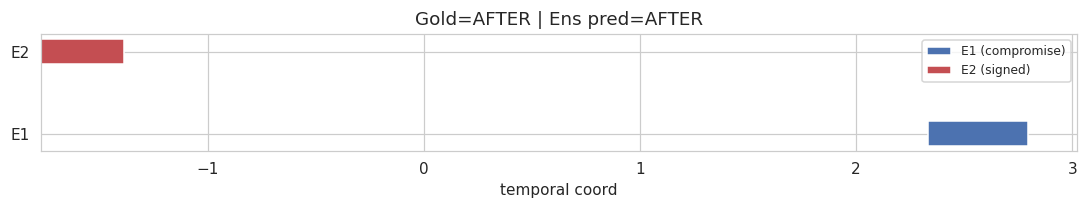

  Geo Logits  (tol=0.127, temp=0.790):
  Class               raw     logit    prob  probability bar            
  ----------------------------------------------------------------------
  BEFORE           -4.564    -5.774   0.000  |                         |
  AFTER            +3.719    +4.706   1.000  |#########################|  <- GOLD
  INCLUDES         -4.232    -5.355   0.000  |                         |
  IS_INCLUDED      -4.305    -5.447   0.000  |                         |
  SIMULTANEOUS     -8.029   -10.159   0.000  |                         |

  => argmax(geo_probs) = AFTER  (khop voi pred_geo)

Doc: APW19980227.0489  |  APW19980227.0489_e3  <->  APW19980227.0489_e4
Gold: AFTER          Pred Sem: AFTER         (1.00)  Pred Geo: AFTER         (1.00)  Pred Ens: AFTER         (1.00)
s1=1.759  e1=2.115  (dur=0.356)
s2=-2.085  e2=-1.640  (dur=0.446)
d_start = s2-s1 = -3.845    d_end = e1-e2 = +3.755
geom_ok (thoa rang buoc gold): True
Entity1: 'investigate'              Entity2: '

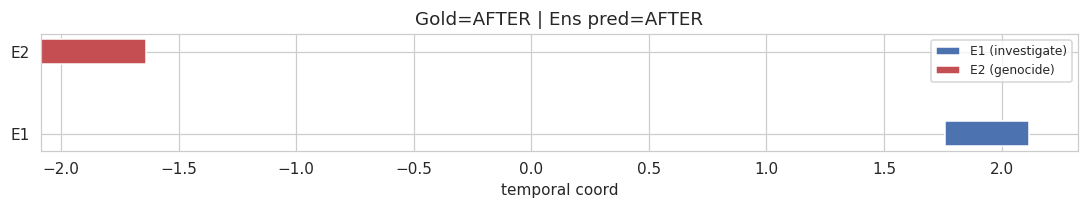

  Geo Logits  (tol=0.127, temp=0.790):
  Class               raw     logit    prob  probability bar            
  ----------------------------------------------------------------------
  BEFORE           -4.200    -5.314   0.000  |                         |
  AFTER            +3.399    +4.300   1.000  |#########################|  <- GOLD
  INCLUDES         -3.972    -5.025   0.000  |                         |
  IS_INCLUDED      -3.882    -4.911   0.000  |                         |
  SIMULTANEOUS     -7.345    -9.294   0.000  |                         |

  => argmax(geo_probs) = AFTER  (khop voi pred_geo)



In [22]:
# ──────────────────────────────────────────────────────────
# CASE 1: Ca 2 DUNG — confidence cao
# ──────────────────────────────────────────────────────────
print("\n+========================================+")
print("|  CASE 1: Ca 2 DUNG (high confidence)  |")
print("+========================================+\n")
good = df[(df.correct_sem == 1) & (df.correct_geo == 1)]\
       .sort_values("conf_ens", ascending=False)
for idx in good.head(2).index:
    show_case(idx)


+====================================================+
|  CASE 2: Geo ĐÚNG — Semantic SAI                  |
+====================================================+

  Tìm thấy 4 trường hợp
  Trong đó: ensemble ĐÚNG (geo_saved) = 4
            ensemble SAI  (sem_drags)  = 0

Doc: CNN19980126.1600.1104  |  CNN19980126.1600.1104_e4  <->  CNN19980126.1600.1104_e42
Gold: AFTER          Pred Sem: SIMULTANEOUS  (0.29)  Pred Geo: AFTER         (0.40)  Pred Ens: AFTER         (0.36)
s1=1.959  e1=2.502  (dur=0.542)
s2=1.439  e2=1.959  (dur=0.521)
d_start = s2-s1 = -0.521    d_end = e1-e2 = +0.542
geom_ok (thoa rang buoc gold): False
Entity1: 'revitalize'               Entity2: 'drop'                   
Err type: geo_saved

  Context:
  CNN19980126.1600.1104 NEWS STORY Major job cuts at AT and T. The long distance giant slashing up to eighteen thousand jobs, freezing executive salaries and shaking up management. The changes are part of a one point six billion dollar cost cutting initiative to >>

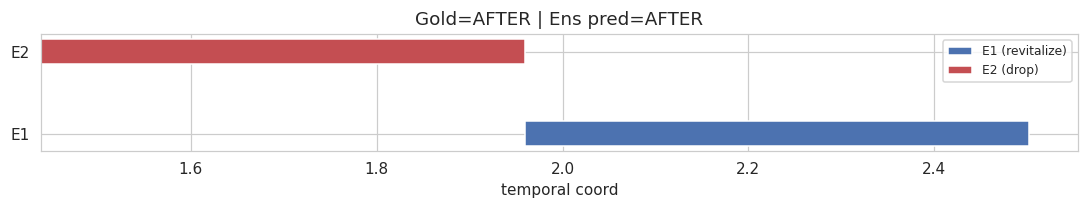

  Geo Logits  (tol=0.127, temp=0.790):
  Class               raw     logit    prob  probability bar            
  ----------------------------------------------------------------------
  BEFORE           -1.063    -1.345   0.105  |###                      |
  AFTER            -0.000    -0.000   0.402  |##########               |  <- GOLD
  INCLUDES         -0.648    -0.820   0.177  |####                     |
  IS_INCLUDED      -0.669    -0.847   0.172  |####                     |
  SIMULTANEOUS     -0.809    -1.024   0.144  |####                     |

  => argmax(geo_probs) = AFTER  (khop voi pred_geo)

Doc: CNN19980126.1600.1104  |  CNN19980126.1600.1104_e48  <->  CNN19980126.1600.1104_e25
Gold: SIMULTANEOUS   Pred Sem: IS_INCLUDED   (0.07)  Pred Geo: SIMULTANEOUS  (0.33)  Pred Ens: SIMULTANEOUS  (0.25)
s1=0.293  e1=0.947  (dur=0.654)
s2=0.355  e2=0.931  (dur=0.576)
d_start = s2-s1 = +0.062    d_end = e1-e2 = +0.016
geom_ok (thoa rang buoc gold): True
Entity1: 'think'               

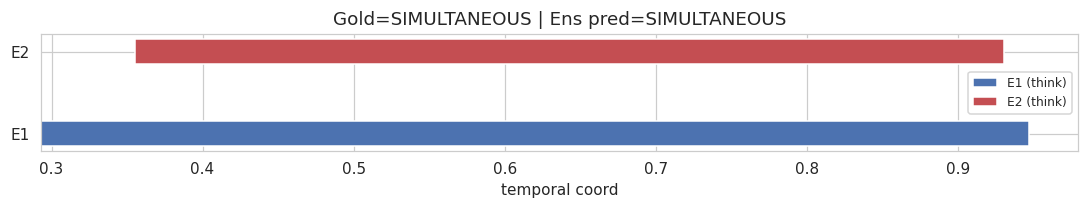

  Geo Logits  (tol=0.127, temp=0.790):
  Class               raw     logit    prob  probability bar            
  ----------------------------------------------------------------------
  BEFORE           -0.592    -0.749   0.124  |###                      |
  AFTER            -0.638    -0.807   0.117  |###                      |
  INCLUDES         -0.111    -0.140   0.227  |######                   |
  IS_INCLUDED      -0.189    -0.239   0.206  |#####                    |
  SIMULTANEOUS     +0.176    +0.222   0.327  |########                 |  <- GOLD

  => argmax(geo_probs) = SIMULTANEOUS  (khop voi pred_geo)



In [23]:
# Case 2: Geo đúng, Sem sai (bất kể ensemble)
print("\n+====================================================+")
print("|  CASE 2: Geo ĐÚNG — Semantic SAI                  |")
print("+====================================================+\n")
geo_right = df[df.branch_status == "geo_right_sem_wrong"].sort_values("conf_geo", ascending=False)
print(f"  Tìm thấy {len(geo_right)} trường hợp")
print(f"  Trong đó: ensemble ĐÚNG (geo_saved) = {(geo_right.correct_ens==1).sum()}")
print(f"            ensemble SAI  (sem_drags)  = {(geo_right.correct_ens==0).sum()}\n")
for idx in geo_right.head(2).index:
    show_case(idx)


+====================================================+
|  CASE 3: Geo SAI — Semantic ĐÚNG                  |
+====================================================+

  Tìm thấy 15 trường hợp
  Trong đó: ensemble ĐÚNG (sem_saved)      = 4
            ensemble SAI  (geo_drags_wrong) = 11

Doc: APW19980227.0489  |  APW19980227.0489_e22  <->  APW19980227.0489_e25
Gold: BEFORE         Pred Sem: BEFORE        (0.46)  Pred Geo: INCLUDES      (0.64)  Pred Ens: INCLUDES      (0.57)
s1=-1.701  e1=1.815  (dur=3.516)
s2=1.348  e2=1.639  (dur=0.291)
d_start = s2-s1 = +3.049    d_end = e1-e2 = +0.176
geom_ok (thoa rang buoc gold): False
Entity1: 'lived'                    Entity2: 'consider'               
Err type: geo_drags_wrong

  Context:
  6, 1994. The assassination touched off a murderous rampage by Hutu security forces and civilians, who slaughtered mainly Tutsis but also Hutus who favored reconciliation with the minority. It also reignited the civil war. The panel also will look at the exod

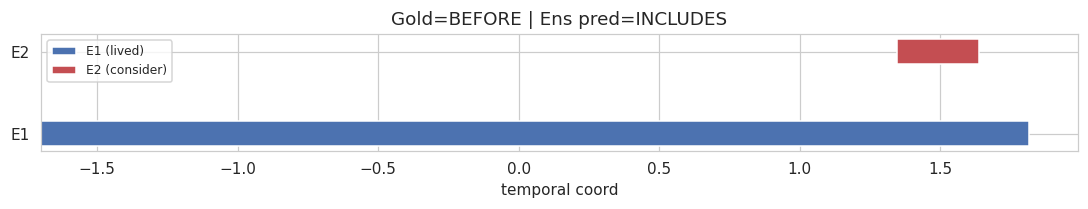

  Geo Logits  (tol=0.127, temp=0.790):
  Class               raw     logit    prob  probability bar            
  ----------------------------------------------------------------------
  BEFORE           -0.467    -0.591   0.331  |########                 |  <- GOLD
  AFTER            -3.340    -4.226   0.009  |                         |
  INCLUDES         +0.049    +0.062   0.636  |################         |
  IS_INCLUDED      -3.176    -4.018   0.011  |                         |
  SIMULTANEOUS     -2.971    -3.759   0.014  |                         |

  => argmax(geo_probs) = INCLUDES  (khop voi pred_geo)

Doc: APW19980308.0201  |  APW19980308.0201_e72  <->  APW19980308.0201_e40
Gold: BEFORE         Pred Sem: BEFORE        (0.25)  Pred Geo: INCLUDES      (0.61)  Pred Ens: INCLUDES      (0.49)
s1=0.059  e1=2.646  (dur=2.587)
s2=2.060  e2=2.484  (dur=0.425)
d_start = s2-s1 = +2.001    d_end = e1-e2 = +0.162
geom_ok (thoa rang buoc gold): False
Entity1: 'spilling'                 Entity

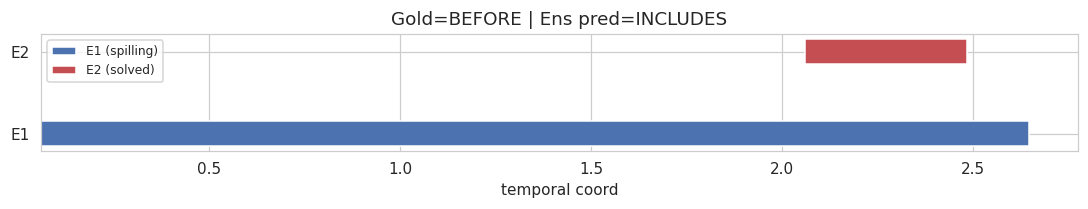

  Geo Logits  (tol=0.127, temp=0.790):
  Class               raw     logit    prob  probability bar            
  ----------------------------------------------------------------------
  BEFORE           -0.587    -0.742   0.276  |#######                  |  <- GOLD
  AFTER            -2.425    -3.069   0.027  |#                        |
  INCLUDES         +0.035    +0.044   0.606  |###############          |
  IS_INCLUDED      -2.128    -2.692   0.039  |#                        |
  SIMULTANEOUS     -1.909    -2.415   0.052  |#                        |

  => argmax(geo_probs) = INCLUDES  (khop voi pred_geo)



In [24]:
# Case 3: Geo sai, Sem đúng (bất kể ensemble)
print("\n+====================================================+")
print("|  CASE 3: Geo SAI — Semantic ĐÚNG                  |")
print("+====================================================+\n")
geo_wrong = df[df.branch_status == "sem_right_geo_wrong"].sort_values("conf_geo", ascending=False)
print(f"  Tìm thấy {len(geo_wrong)} trường hợp")
print(f"  Trong đó: ensemble ĐÚNG (sem_saved)      = {(geo_wrong.correct_ens==1).sum()}")
print(f"            ensemble SAI  (geo_drags_wrong) = {(geo_wrong.correct_ens==0).sum()}\n")
for idx in geo_wrong.head(2).index:
    show_case(idx)


+===============================================+
|  CASE 4: Ca 2 SAI (both_wrong)|
+===============================================+

  Tim thay 100 truong hop.
  Phan bo gold label: {'AFTER': 27, 'INCLUDES': 23, 'BEFORE': 21, 'IS_INCLUDED': 16, 'SIMULTANEOUS': 13}

Doc: PRI19980306.2000.1675  |  PRI19980306.2000.1675_e5  <->  PRI19980306.2000.1675_e8
Gold: INCLUDES       Pred Sem: BEFORE        (0.99)  Pred Geo: BEFORE        (1.00)  Pred Ens: BEFORE        (1.00)
s1=-1.501  e1=-1.073  (dur=0.428)
s2=2.120  e2=2.528  (dur=0.408)
d_start = s2-s1 = +3.620    d_end = e1-e2 = -3.601
geom_ok (thoa rang buoc gold): False
Entity1: 'taking'                   Entity2: 'move'                   
Err type: both_wrong

  Context:
  the BBC news room in London. More heavy gunfire in the Serbian province of Kosovo. It's the second day of an offensive by the security forces against villages populated by ethnic Albanians. BBC correspondent Karyn Coleman reports from Kosovo. There were more accounts 

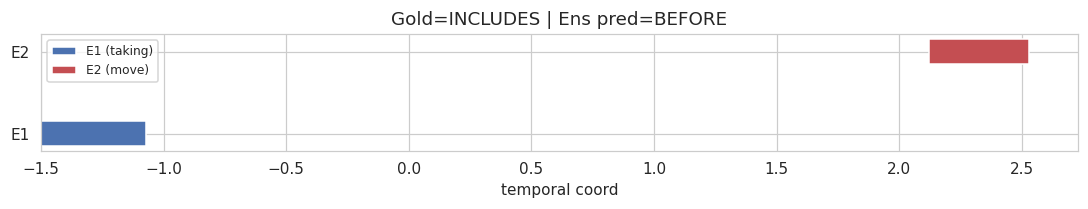

  Geo Logits  (tol=0.127, temp=0.790):
  Class               raw     logit    prob  probability bar            
  ----------------------------------------------------------------------
  BEFORE           +3.193    +4.040   1.000  |#########################|
  AFTER            -4.028    -5.097   0.000  |                         |
  INCLUDES         -3.728    -4.717   0.000  |                         |  <- GOLD
  IS_INCLUDED      -3.747    -4.741   0.000  |                         |
  SIMULTANEOUS     -6.967    -8.815   0.000  |                         |

  => argmax(geo_probs) = BEFORE  (khop voi pred_geo)

Doc: PRI19980306.2000.1675  |  PRI19980306.2000.1675_e27  <->  PRI19980306.2000.1675_e37
Gold: IS_INCLUDED    Pred Sem: BEFORE        (0.99)  Pred Geo: BEFORE        (1.00)  Pred Ens: BEFORE        (1.00)
s1=-1.208  e1=-0.323  (dur=0.885)
s2=2.496  e2=3.045  (dur=0.549)
d_start = s2-s1 = +3.704    d_end = e1-e2 = -3.368
geom_ok (thoa rang buoc gold): False
Entity1: 'attack'          

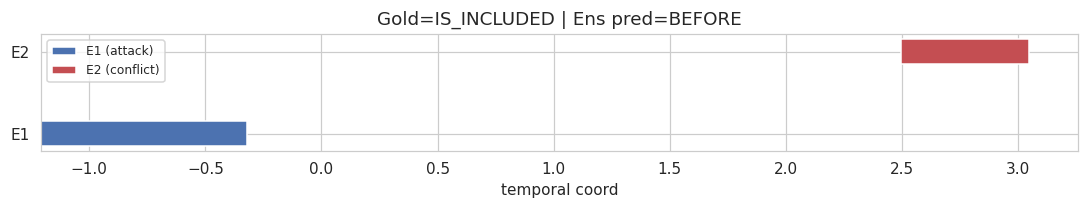

  Geo Logits  (tol=0.127, temp=0.790):
  Class               raw     logit    prob  probability bar            
  ----------------------------------------------------------------------
  BEFORE           +2.819    +3.567   0.999  |#########################|
  AFTER            -4.253    -5.381   0.000  |                         |
  INCLUDES         -3.495    -4.421   0.000  |                         |
  IS_INCLUDED      -3.831    -4.847   0.000  |                         |  <- GOLD
  SIMULTANEOUS     -6.818    -8.626   0.000  |                         |

  => argmax(geo_probs) = BEFORE  (khop voi pred_geo)



In [25]:
# ──────────────────────────────────────────────────────────
# CASE 4: Ca 2 SAI — loi he thong
# ──────────────────────────────────────────────────────────
print("\n+===============================================+")
print("|  CASE 4: Ca 2 SAI (both_wrong)|")
print("+===============================================+\n")
both_err = df[df.err_type == "both_wrong"].sort_values("conf_ens", ascending=False)
print(f"  Tim thay {len(both_err)} truong hop.")
print(f"  Phan bo gold label: {both_err.label_name.value_counts().to_dict()}\n")
for idx in both_err.head(2).index:
    show_case(idx)

---
## §G. Xuất kết quả

In [26]:
import shutil

# Zip toàn bộ thư mục OUT_DIR thành 1 file
shutil.make_archive(
    base_name="/kaggle/working/geo_analysis_result",  # tên file zip (không có .zip)
    format="zip",
    root_dir=OUT_DIR   # thư mục cần zip
)

print("Done! Tai ve file: /kaggle/working/geo_analysis_result.zip")

Done! Tai ve file: /kaggle/working/geo_analysis_result.zip
